In [32]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [33]:
business_dir = "../artifacts/business"
figure_dir = "../artifacts/figures"

os.makedirs(business_dir,exist_ok=True)
os.makedirs(figure_dir,exist_ok=True)

In [34]:
file_path = "../data/processed/cleaned_customer_churn.csv"

df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Dataset Shape:")
print(df.shape)

Dataset loaded successfully.
Dataset Shape:
(7043, 21)


In [35]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

df["TotalCharges"] = (df["TotalCharges"].fillna(0))

In [36]:
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"No": 0,"Yes": 1})

print("Churn Distribution:")
print(df["Churn"].value_counts())

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [37]:
model_path = "../artifacts/models/best_churn_model.pkl"

best_model = joblib.load(model_path)

In [38]:
X = df.drop(columns=["customerID","Churn"])

In [39]:
df["ChurnProbability"] = (best_model.predict_proba(X)[:, 1])

df["PredictedChurn"] = (best_model.predict(X))
print("Churn probability generated ""for all customers.")

Churn probability generated for all customers.


In [40]:
def assign_risk_level(probability):
    if probability >= 0.75:
        return "Very High Risk"
    elif probability >= 0.50:
        return "High Risk"
    elif probability >= 0.25:
        return "Medium Risk"
    else:
        return "Low Risk"

df["RiskLevel"] = (df["ChurnProbability"].apply(assign_risk_level))
print("Risk Level Distribution:")
print(df["RiskLevel"].value_counts())

Risk Level Distribution:
RiskLevel
Low Risk          2703
Very High Risk    1454
Medium Risk       1450
High Risk         1436
Name: count, dtype: int64


In [41]:
active_customers = (df[df["Churn"] == 0].copy())
print("Number of Active Customers:")
print(len(active_customers))

Number of Active Customers:
5174


In [42]:
high_value_threshold = (df["MonthlyCharges"].quantile(0.75))

print("High-Value Monthly Charge Threshold:")
print(round(high_value_threshold,2))

active_customers["HighValueCustomer"] = (active_customers["MonthlyCharges"]>= high_value_threshold)


High-Value Monthly Charge Threshold:
89.85


In [43]:
def assign_priority(row):
    probability = row["ChurnProbability"]
    high_value = row["HighValueCustomer"]

    # Highest priority = high probability + high value
    if (probability >= 0.75 and high_value):
        return "Priority 1"

    # Very high churn probability
    elif probability >= 0.75:
        return "Priority 2"
    
    # High probability + high value
    elif (probability >= 0.50 and high_value):
        return "Priority 2"

    # General high-risk customers
    elif probability >= 0.50:
        return "Priority 3"
    # Medium risk
    elif probability >= 0.25:
        return "Monitor"
    else:
        return "Low Priority"

active_customers["RetentionPriority"] = (active_customers.apply(assign_priority,axis=1))

print("Retention Priority Distribution:")

print(active_customers["RetentionPriority"].value_counts())

Retention Priority Distribution:
RetentionPriority
Low Priority    2592
Monitor         1189
Priority 3       625
Priority 2       610
Priority 1       158
Name: count, dtype: int64


In [44]:
def generate_recommendations(row):
    recommendations = []

    # MONTH-TO-MONTH CONTRACT
    if row["Contract"] == "Month-to-month":
        recommendations.append("Offer incentive to move to a long-term contract")

    # ELECTRONIC CHECK
    if row["PaymentMethod"] == "Electronic check":
        recommendations.append("Encourage automatic payment adoption")

    # NEW CUSTOMERS
    if row["tenure"] <= 12:
        recommendations.append("Provide proactive onboarding and early engagement")

    # HIGH MONTHLY CHARGES
    if row["MonthlyCharges"] >= high_value_threshold:
        recommendations.append("Conduct plan review or provide personalized retention offer")

    # NO TECH SUPPORT
    if (row["TechSupport"] == "No"and row["InternetService"] != "No"):
        recommendations.append("Offer trial or discounted technical support")

    # NO ONLINE SECURITY

    if (row["OnlineSecurity"] == "No"and row["InternetService"] != "No"):
        recommendations.append("Promote bundled online security services")

    # FALLBACK RECOMMENDATION
    if len(recommendations) == 0:
        recommendations.append("Use loyalty and customer-engagement campaign")

    return " | ".join(recommendations[:3])


In [45]:
active_customers["RecommendedAction"] = (active_customers.apply(generate_recommendations,axis=1))


In [46]:
retention_targets = (active_customers[active_customers["RetentionPriority"].isin(["Priority 1","Priority 2","Priority 3"])].copy())

In [47]:
priority_order = {"Priority 1": 1,"Priority 2": 2,"Priority 3": 3}

retention_targets["PriorityOrder"] = (retention_targets["RetentionPriority"].map(priority_order))


retention_targets = (retention_targets.sort_values(["PriorityOrder","ChurnProbability","MonthlyCharges"],ascending=[True,False,False]))

In [48]:
print("Number of Retention Targets:")
print(len(retention_targets))

print("Top Retention Targets:")
print(retention_targets[[
            "customerID",
            "tenure",
            "Contract",
            "PaymentMethod",
            "MonthlyCharges",
            "ChurnProbability",
            "RiskLevel",
            "RetentionPriority",
            "RecommendedAction"
        ]].head(20))


Number of Retention Targets:
1393
Top Retention Targets:
      customerID  tenure        Contract     PaymentMethod  MonthlyCharges  \
3159  5150-ITWWB       3  Month-to-month  Electronic check           94.85   
4039  8161-QYMTT       7  Month-to-month  Electronic check           94.10   
4618  6350-XFYGW       4  Month-to-month  Electronic check           94.75   
5213  7668-XCFYV      17  Month-to-month  Electronic check           92.55   
5019  3320-VEOYC      14  Month-to-month  Electronic check           95.60   
3954  7225-CBZPL      17  Month-to-month  Electronic check           94.80   
1725  5935-FCCNB      17  Month-to-month  Electronic check           94.20   
2519  4927-WWOOZ       2  Month-to-month  Electronic check           91.45   
4124  3452-GWUIN      19  Month-to-month  Electronic check           94.95   
1903  3318-NMQXL       3  Month-to-month  Electronic check           92.00   
6574  6969-MVBAI       9  Month-to-month  Electronic check           90.10   
1724  7

In [49]:
priority_summary = (retention_targets.groupby("RetentionPriority").agg(
        Customers=("customerID","count"),
        Average_Churn_Probability=("ChurnProbability","mean"),
        Average_Monthly_Charges=("MonthlyCharges","mean"),
        Total_Monthly_Charges=("MonthlyCharges","sum"
        )).reset_index())

priority_summary["Average_Churn_Probability"] = (priority_summary["Average_Churn_Probability"]* 100).round(2)

print("Priority Summary:")
print(priority_summary)

Priority Summary:
  RetentionPriority  Customers  Average_Churn_Probability  \
0        Priority 1        158                      82.58   
1        Priority 2        610                      72.68   
2        Priority 3        625                      62.25   

   Average_Monthly_Charges  Total_Monthly_Charges  
0                97.505696               15405.90  
1                85.569098               52197.15  
2                59.997280               37498.30  


In [50]:

monthly_charges_targeted = (retention_targets["MonthlyCharges"].sum())
print("Total Monthly Charges Associated With Retention Targets:")
print(round(monthly_charges_targeted,2))


Total Monthly Charges Associated With Retention Targets:
105101.35


In [51]:
expected_active_churn = (active_customers["ChurnProbability"].sum())

expected_target_churn = (retention_targets["ChurnProbability"].sum())

print("Model-Estimated Expected Churn Among Active Customers:")
print(round(expected_active_churn,2))
print("Model-Estimated Expected Churn Within Retention Targets:")
print(round(expected_target_churn,2))

Model-Estimated Expected Churn Among Active Customers:
1640.04
Model-Estimated Expected Churn Within Retention Targets:
962.88


In [52]:
expected_churn_rate = (expected_active_churn/len(active_customers))

print("Estimated Churn Risk Across Active Customers:")
print(f"{expected_churn_rate * 100:.2f}%")


Estimated Churn Risk Across Active Customers:
31.70%


In [53]:
scenario_effectiveness = [0.10,0.20,0.30]
impact_results = []

In [54]:
for effectiveness in scenario_effectiveness:
    prevented_churn = (expected_target_churn* effectiveness)

    new_expected_churn = (expected_active_churn- prevented_churn)

    new_expected_churn_rate = (new_expected_churn/len(active_customers))
    
    churn_rate_reduction = (expected_churn_rate-new_expected_churn_rate)

    expected_monthly_revenue_protected = (
        retention_targets["MonthlyCharges"] * retention_targets["ChurnProbability"] * effectiveness).sum()

    annual_revenue_protected = (expected_monthly_revenue_protected * 12)

    impact_results.append({
            "Retention_Effectiveness":effectiveness,
            "Expected_Churn_Prevented":prevented_churn,
            "Expected_Churn_Rate_Before":expected_churn_rate,
            "Expected_Churn_Rate_After":new_expected_churn_rate,
            "Expected_Churn_Rate_Reduction":churn_rate_reduction,
            "Expected_Monthly_Revenue_Protected":expected_monthly_revenue_protected,
            "Expected_Annual_Revenue_Protected":annual_revenue_protected
        })


In [55]:
impact_df = pd.DataFrame(impact_results)

In [56]:

impact_df["Retention_Effectiveness"] = (impact_df["Retention_Effectiveness"] * 100)

impact_df["Expected_Churn_Rate_Before"] = (impact_df["Expected_Churn_Rate_Before"] * 100)

impact_df["Expected_Churn_Rate_After"] = (impact_df["Expected_Churn_Rate_After"] * 100)

impact_df["Expected_Churn_Rate_Reduction"] = (impact_df["Expected_Churn_Rate_Reduction"] * 100)


In [57]:

impact_df = impact_df.round(2)
print("Retention Impact Scenarios:")
print(impact_df)


Retention Impact Scenarios:
   Retention_Effectiveness  Expected_Churn_Prevented  \
0                     10.0                     96.29   
1                     20.0                    192.58   
2                     30.0                    288.86   

   Expected_Churn_Rate_Before  Expected_Churn_Rate_After  \
0                        31.7                      29.84   
1                        31.7                      27.98   
2                        31.7                      26.11   

   Expected_Churn_Rate_Reduction  Expected_Monthly_Revenue_Protected  \
0                           1.86                             7339.94   
1                           3.72                            14679.89   
2                           5.58                            22019.83   

   Expected_Annual_Revenue_Protected  
0                           88079.33  
1                          176158.66  
2                          264237.99  


In [58]:

month_to_month_targets = (retention_targets[retention_targets["Contract"] == "Month-to-month"])
print("Month-to-Month Retention Targets:")
print(len(month_to_month_targets))


Month-to-Month Retention Targets:
1304


In [59]:
electronic_check_targets = (retention_targets[retention_targets["PaymentMethod"] == "Electronic check"])

print("Electronic Check Retention Targets:")
print(len(electronic_check_targets))



Electronic Check Retention Targets:
758


In [60]:

new_customer_targets = (retention_targets[retention_targets["tenure"] <= 12])
print("New-Customer Retention Targets:")
print(len(new_customer_targets))


New-Customer Retention Targets:
620


In [61]:
high_value_targets = (retention_targets[retention_targets["HighValueCustomer"] == True])
print("High-Value Retention Targets:")
print(len(high_value_targets))


High-Value Retention Targets:
450


AttributeError: 'Series' object has no attribute 'value'

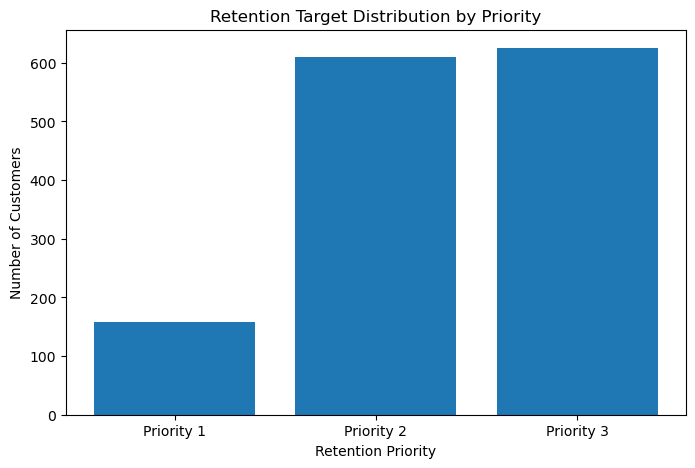

In [64]:
priority_counts = (retention_targets["RetentionPriority"].value_counts().reindex(
        [
            "Priority 1",
            "Priority 2",
            "Priority 3"
        ]
        ).fillna(0))
plt.figure(figsize=(8, 5))

plt.bar(priority_counts.index,priority_counts.values)

plt.title("Retention Target Distribution by Priority")
plt.xlabel("Retention Priority")
plt.ylabel("Number of Customers")

for index, value in enumerate(priority_counts.value):
    plt.text(index,value,str(int(value)),ha="center",va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(figure_dir,"retention_priority_distribution.png"),dpi=300)

plt.show()


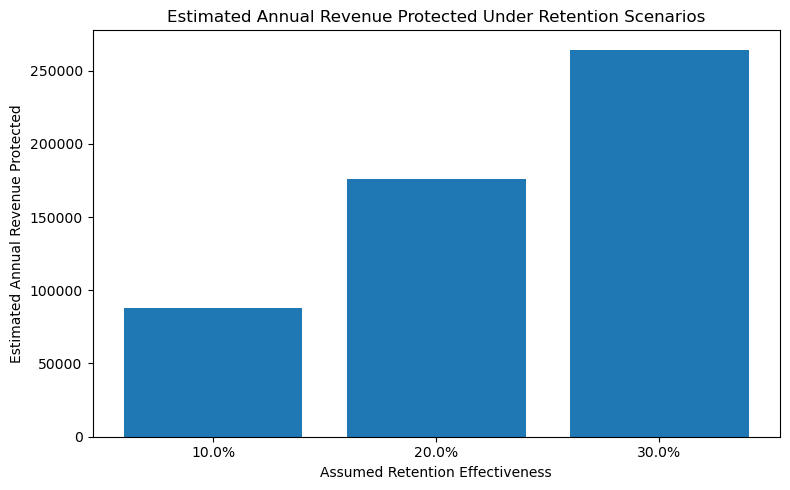

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(impact_df["Retention_Effectiveness"].astype(str) + "%",impact_df["Expected_Annual_Revenue_Protected"])

plt.title("Estimated Annual Revenue Protected Under Retention Scenarios")
plt.xlabel("Assumed Retention Effectiveness")
plt.ylabel("Estimated Annual Revenue Protected")

plt.tight_layout()
plt.savefig(os.path.join(figure_dir,"retention_revenue_impact.png"),dpi=300)
plt.show()


In [65]:
retention_targets.to_csv(os.path.join(business_dir,"retention_priority_customers.csv"),index=False)


In [67]:
priority_summary.to_csv(os.path.join(business_dir,"retention_priority_summary.csv"),index=False)


In [68]:
impact_df.to_csv(os.path.join(business_dir,"retention_impact_scenarios.csv"),index=False)


In [69]:
active_customers.to_csv(os.path.join(business_dir,"scored_active_customers.csv"),index=False)


In [70]:
print("TASK 6 - BUSINESS RECOMMENDATION SUMMARY")

print(f"Active Customers: "f"{len(active_customers)}")
print(f"Retention Targets: "f"{len(retention_targets)}")
print(f"High-Value Targets: "f"{len(high_value_targets)}")
print(f"Month-to-Month Targets: "f"{len(month_to_month_targets)}")
print(f"Electronic Check Targets: "f"{len(electronic_check_targets)}")
print(f"New Customer Targets: "f"{len(new_customer_targets)}")
print("Task 6 completed successfully.")

TASK 6 - BUSINESS RECOMMENDATION SUMMARY
Active Customers: 5174
Retention Targets: 1393
High-Value Targets: 450
Month-to-Month Targets: 1304
Electronic Check Targets: 758
New Customer Targets: 620
Task 6 completed successfully.
